In [ ]:
"""
绘制搜索引擎upset图
"""

In [236]:
"""
获取所有搜索引擎：
    - Original pFind
    - pFind
    - MSFragger
    - MaxQuant
    - Comet
    的肽段层次结果，并向pFind对齐
"""


"""
=================================================== pFind: pFind-Filtered.spectra ==================================================
"""
def get_pfind_res(path):
    print(path)
    peptides = set()
    
    f = open(path,"r")
    next(f,None)
    for i,line in enumerate(f):
        items = line.split("\t")
        peptide = items[5]+'\t'+items[10]  # seq+mod
        is_decoy = (items[15]=="decoy")
        # proteins = items[12].split("/")[:-1]
        # flag = True
        # for protein in proteins:
        #     if not protein.endswith("_ARATH"):
        #         flag = False
        #         break
        if is_decoy:
            continue
        peptides.add(peptide)
    f.close()
    return peptides

"""
============================================= MSFragger: peptide level q_value = 0.01 ==============================================
"""
def translate(msfragger_mod):
    msfragger2pfind = {
        "N-term(42.0106)": "Acetyl[Protein-Nterm]",
        "M(15.9949)": "Oxidation[M]",
        "C(57.0214)": "Carbamidomethyl[C]",
        "N(0.9840)": "Deamidated[N]"
    }
    result = list()
    for mod in msfragger_mod.split(", "):
        if mod == '':
            break
        p = 0
        for i in range(len(mod)):
            if not '0'<=mod[i]<='9':
                p = i
                break
        pos = 0 if p==0 else int(mod[:p])
        name = msfragger2pfind[mod[p:]]
        result.append([pos,name])
    result = sorted(result, key=lambda item: item[0])
    pfind_mod = ""
    for pos,name in result:
        pfind_mod += f"{pos},{name};"
    return pfind_mod
            
def get_msfragger_res(path):
    print(path)
    peptides = set()
    f = open(path, "r")
    next(f,None)
    for line in f:
        items = line.split("\t")
        seq = items[0]
        mod = translate(items[10])
        peptide = seq+'\t'+mod  # seq+mod
        
        proteins = [items[12]]
        for protein in items[-1].split(","):
            if protein != '\n':
                proteins.append(protein.strip())
        flag = False
        for protein in proteins:
            if not protein.startswith("REV_"):
                flag = True
                break
        if not flag:
            continue

        peptides.add(peptide)
    f.close()
    return peptides

"""
====================================================== MaxQuant: msms.txt ==========================================================
"""
def extract_parentheses_info(sequence):
    maxquant2pfind = {
        "Acetyl (Protein N-term)": "Acetyl[Protein-Nterm]",
        "Oxidation (M)": "Oxidation[M]",
        "Deamidated (N)": "Deamidated[N]"
    }
    pfind_mod = ""  # 位置,内容;
    purified = []  # 构建净化序列（仅正常字母）
    i = 0
    n = len(sequence)
    while i < n:
        if sequence[i] == '(':
            # 1. 找最外层对应的)：用计数法处理嵌套
            count = 1  # 初始计数为1（当前(）
            j = i + 1
            while j < n and count != 0:
                if sequence[j] == '(':
                    count += 1  # 遇到内层(，计数+1
                elif sequence[j] == ')':
                    count -= 1  # 遇到)，计数-1
                j += 1
            # 若找到完整的最外层()（count归0）
            if count == 0:
                # 2. 提取最外层(...)的内容（不含外层括号）
                # j-1是最外层)的位置，所以内容是[i+1 : j-1]
                parentheses_content = sequence[i+1 : j-1]
                # 3. 计算位置（规则同前：开头为0，否则为前一个字母的序号）
                insert_index = len(purified)
                position = 0 if insert_index == 0 else insert_index
                # 4. 存储结果
                pfind_mod += f"{position},{maxquant2pfind[parentheses_content]};"
                # 5. 跳过当前最外层()，继续遍历
                i = j
            else:
                # 若没有找到对应的)（不完整的(），则将(视为普通字符
                purified.append(sequence[i])
                i += 1
        elif sequence[i] == "C":
            purified.append(sequence[i])
            insert_index = len(purified)
            pfind_mod += f"{insert_index},Carbamidomethyl[C];"
            i += 1
        else:
            # 非(字符：加入净化序列
            purified.append(sequence[i])
            i += 1
    
    purified_sequence = ''.join(purified)
    return purified_sequence, pfind_mod
    
def get_maxquant_res(path):
    print(path)
    peptides = set()
    f = open(path, "r")
    next(f,None)
    for line in f:
        items = line.strip().split("\t")
        peptide = items[7][1:-1]
        seq, mod = extract_parentheses_info(peptide)
        peptide = seq+'\t'+mod
        proteins = items[12].split(";")
        if len(proteins)==0 or proteins[0] == "":
            # decoy_num += 1
            continue
        # flag = True
        # for protein in proteins:
        #     if not protein.endswith("_ARATH"):
        #         flag = False
        #         break
        # if flag and peptide not in peptides:
        #     trapped_num += 1
        peptides.add(peptide)
    f.close()
    return peptides

"""
============================================== Comet: peptide_results.txt ==========================================================
"""
def extract_bracketed_info(sequence):
    comet2pfind = {
        "15.9949": "Oxidation[M]",
        "42.0106": "Acetyl[Protein-Nterm]",
        "0.9840": "Deamidated[N]"
    }
    pfind_mod = ""  # 位置,mod;
    purified = []  # 构建净化序列（仅正常字母）
    i = 0
    n = len(sequence)
    while i < n:
        if sequence[i] == '[':
            # 1. 找到当前[对应的]的位置
            j = sequence.find(']', i + 1)
            if j == -1:  # 处理不完整的[]（跳过）
                i += 1
                continue
            # 2. 提取[xxx]中的内容
            bracketed_content = sequence[i+1:j]
            # 3. 计算[]的位置（核心修正逻辑）
            # 净化序列当前长度 = []插入点在净化序列中的下标（如插入开头，长度=0；插入A后，长度=1）
            insert_index = len(purified)
            if insert_index == 0:
                # 情况1：[]在开头（插入点下标0，左侧无字母）→ 位置0
                position = 0
            else:
                # 情况2：[]在中间/结尾（左侧有字母，位置=左侧最后一个字母的序号=insert_index）
                # 因为insert_index = 左侧最后一个字母的下标 + 1（例如左侧有A(0)，insert_index=1→位置1）
                position = insert_index
            # 4. 存储结果
            pfind_mod += f"{position},{comet2pfind[bracketed_content]};"
            # 5. 跳过当前[]，继续遍历
            i = j + 1
        elif sequence[i] == "C":  # 固定修饰
            purified.append(sequence[i])
            insert_index = len(purified)
            pfind_mod += f"{insert_index},Carbamidomethyl[C];"
            i += 1
        else:
            # 非[]内容：加入净化序列
            purified.append(sequence[i])
            i += 1
    purified_sequence = ''.join(purified)
    return purified_sequence, pfind_mod
    
def get_comet_res(path):
    print(path)
    peptides = set()
    
    f = open(path, "r")
    next(f,None)
    for line in f:
        items = line.strip().split("\t")
        q_value = float(items[2])
        if q_value > 0.01:
            break
        peptide = items[4][2:-2]
        if peptide[0]=='n':
            peptide = peptide[1:]
        seq, mod = extract_bracketed_info(peptide)
        peptide = seq+'\t'+mod
        
        proteins = items[5:]
        flag = False
        for protein in proteins:
            if not protein.startswith("DECOY_"):
                flag = True
                break
        if not flag:
            continue
        # flag = True
        # for protein in proteins:
        #     if not protein.endswith("_ARATH"):
        #         flag = False
        #         break
        # if flag and pep not in peptides:
        #     trapped_num += 1
        peptides.add(peptide)
        # peptides.add(seq)
    f.close()
    return peptides


# # Astral
# pfind_result_path = "D:/pFindWorkspace/Astral/new/top50-complete/result/restricted-0627/pFind-Filtered.spectra"
# msfragger_result_path = "G:/MSFraggerWorkspace/Astral/top50-restricted/peptide.tsv"
# maxquant_result_path = "G:/MaxQuantWorkspace/Astral/top50/combined/txt/msms.txt"
# comet_result_path = "G:/CometWorkspace/Astral/top50/peptide_results.txt"
# humangut
pfind_result_path = "D:/pFindWorkspace/MetaProteomics/humangut-new/result/restricted/pFind-Filtered.spectra"
msfragger_result_path = "G:/MSFraggerWorkspace/MetaProteomics/humangut/restricted/peptide.tsv"
# maxquant_result_path = "G:/MaxQuantWorkspace/Humangut/combined/txt/msms.txt"
comet_result_path = "G:/CometWorkspace/humangut/peptide_results.txt"
pfind_res = get_pfind_res(pfind_result_path)
msfragger_res = get_msfragger_res(msfragger_result_path)
maxquant_res = get_maxquant_res(maxquant_result_path)
comet_res = get_comet_res(comet_result_path)

G:/CometWorkspace/humangut/peptide_results.txt


In [134]:
for i,res in enumerate(comet_res):
    print(res)
    if i>100:
        break

31142


In [238]:
"""
求交集：
    求目标搜索引擎与其余各搜索引擎的交集
"""
import pandas as pd
import itertools

target = pfind_res
others = [msfragger_res, maxquant_res, comet_res]
index_names = ['pFind', 'MSFragger', 'MaxQuant', 'Comet']
# 获取其他搜索引擎的数量
n_others = len(others)
if n_others == 0:
    raise ValueError("至少需要一个其他搜索引擎的结果")

# 生成其他搜索引擎的所有可能组合（2^n种）
# 每种组合用布尔值表示：True表示包含该搜索引擎，False表示不包含
other_combinations = list(itertools.product([False, True], repeat=n_others))

# 准备结果数据
data = {}

# 目标搜索引擎必须为True，遍历其他搜索引擎的所有组合
for combo in other_combinations:
    # 必须包含目标搜索引擎
    current_set = target.copy()
    
    # 处理组合中为True的搜索引擎（取交集）
    for i, include in enumerate(combo):
        if include:
            current_set &= others[i]
    
    # 处理组合中为False的搜索引擎（排除这些搜索引擎中的肽段）
    excluded = set()
    for i, include in enumerate(combo):
        if not include:
            excluded.update(others[i])
    current_set -= excluded
    
    # 记录当前组合的计数
    # 索引构建：(目标是否包含, 其他1是否包含, 其他2是否包含, ...)
    index_tuple = (True,) + combo
    data[index_tuple] = len(current_set)

# 转换为pandas Series并设置索引名称
series = pd.Series(data, name='value')

# 设置索引名称（目标搜索引擎为'target'，其他为'other_0', 'other_1', ...）

series.index.names = index_names

print(series)

pFind  MSFragger  MaxQuant  Comet
True   False      False     False    41617
                            True         0
                  True      False        8
                            True         0
       True       False     False    64990
                            True         0
                  True      False       11
                            True         0
Name: value, dtype: int64


In [240]:
"""
求交集：
    求各搜索引擎的交集
"""
import pandas as pd
import itertools

# target = pfind_res
# others = [msfragger_res, maxquant_res, comet_res]
totals = [pfind_res, msfragger_res, maxquant_res, comet_res]
index_names = ['pFind', 'MSFragger', 'MaxQuant', 'Comet']
# 获取其他搜索引擎的数量
n_total = len(totals)

# 生成其他搜索引擎的所有可能组合（2^n种）
# 每种组合用布尔值表示：True表示包含该搜索引擎，False表示不包含
combinations = list(itertools.product([False, True], repeat=n_total))
total_set = set()
for i in totals:
    total_set |= i

# 准备结果数据
data = {}
# 目标搜索引擎必须为True，遍历其他搜索引擎的所有组合
for combo in combinations:
    if not any(combo):
        continue
    # 必须包含目标搜索引擎
    current_set = total_set.copy()
    
    # 处理组合中为True的搜索引擎（取交集）
    for i, include in enumerate(combo):
        if include:
            current_set &= totals[i]
    
    # 处理组合中为False的搜索引擎（排除这些搜索引擎中的肽段）
    excluded = set()
    for i, include in enumerate(combo):
        if not include:
            excluded.update(totals[i])
    current_set -= excluded
    
    # 记录当前组合的计数
    # 索引构建：(目标是否包含, 其他1是否包含, 其他2是否包含, ...)
    index_tuple = combo
    data[index_tuple] = len(current_set)

    if combo == (False,False,False,True):
        a = current_set

# 转换为pandas Series并设置索引名称
series = pd.Series(data, name='value')

# 设置索引名称（目标搜索引擎为'target'，其他为'other_0', 'other_1', ...）

series.index.names = index_names

print(series)

pFind  MSFragger  MaxQuant  Comet
False  False      False     True     79833
                  True      False    20790
                            True         0
       True       False     False    13217
                            True         0
                  True      False        5
                            True         0
True   False      False     False    41617
                            True         0
                  True      False        8
                            True         0
       True       False     False    64990
                            True         0
                  True      False       11
                            True         0
Name: value, dtype: int64


In [234]:
for i,j in enumerate(a):
    if i>100:
        break
    print(j)

VNLDPAESVAYLIGK	2,Deamidated[N];
ESDGAIFNNAGQVLNHNLYFTQFSPNGGGEPTGK	15,Deamidated[N];17,Deamidated[N];
LATYTNPVTPAQANDQDFTQNQQLVLDNK	14,Deamidated[N];
DMNLRPVEGVSGLNTDEEILAVLKK	14,Deamidated[N];
ADHVNALWNIIDWDVVEK	5,Deamidated[N];
STTYQLDNIIIGNDIPVLVK	8,Deamidated[N];
YGNLFDMYEEITDVNPGELANEINGVK	7,Oxidation[M];15,Deamidated[N];21,Deamidated[N];24,Deamidated[N];
VGIDKNYTAMTLANATNTIEIHTGTAK	17,Deamidated[N];
NIASEYGEYNIQCNGIGPGYIATPQTAPLRER	1,Deamidated[N];13,Carbamidomethyl[C];14,Deamidated[N];
LLCGAGVGITGNMMER	3,Carbamidomethyl[C];14,Oxidation[M];
NYVLSTVAQNKLTELTATVAGDTK	10,Deamidated[N];
KGANVLFVDESIFPQNLAVIQTR	4,Deamidated[N];16,Deamidated[N];
AYIVNNDDAPNYKPEYSGHR	11,Deamidated[N];
EKIEAKEAELEK	
VLNDNWGIKDGLMTTVHSTTATQK	3,Deamidated[N];5,Deamidated[N];
NGSADKEDNVLVNAPHPEYEVVANEWNHSYSR	1,Deamidated[N];9,Deamidated[N];13,Deamidated[N];
ANEQNVAHMPAYQWVVLK	2,Deamidated[N];5,Deamidated[N];
SNMFEEVKGELTLAAEHEYGIYAK	
DGDNVGTSGFTPSGYPK	4,Deamidated[N];
LYGVNSIPATVLVDQDGTIIAR	
IELAFENHR	7,De

G:\downloads\anaconda3\Lib\site-packages\upsetplot\plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
G:\downloads\anaconda3\Lib\site-packages\upsetplot\plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exampl

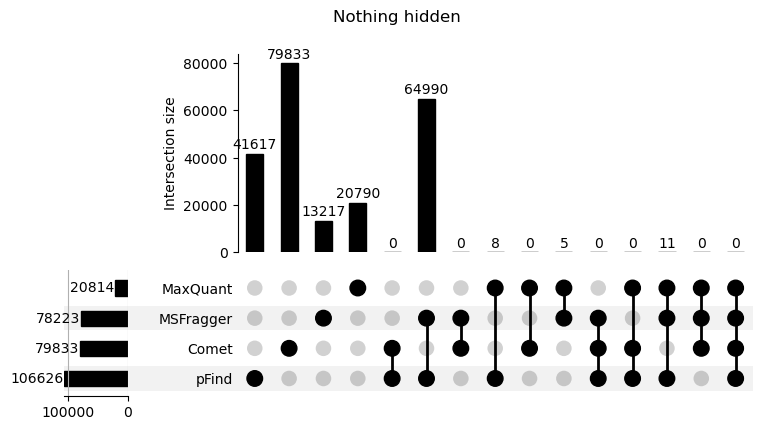

In [242]:
from matplotlib import pyplot as plt
from upsetplot import generate_counts, plot, UpSet

plot(series, show_counts=True)
plt.grid(False)
plt.suptitle('Nothing hidden')
plt.show()

In [202]:
len(msfragger_res)

34050